In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

df_train = pd.read_csv('../data/KDDTrain.txt', names=col_names)
df_test = pd.read_csv('../data/KDDTest.txt', names=col_names)


head = df_train.head()
null_values = df_train.isnull().sum()

print(head, null_values)

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [3]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [4]:
df_train['label'].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [5]:
df_train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty_level
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [6]:
df_train['binary_label'] = (df_train['label'] != 'normal').astype(int)
df_train['binary_label'].value_counts()

binary_label
0    67343
1    58630
Name: count, dtype: int64

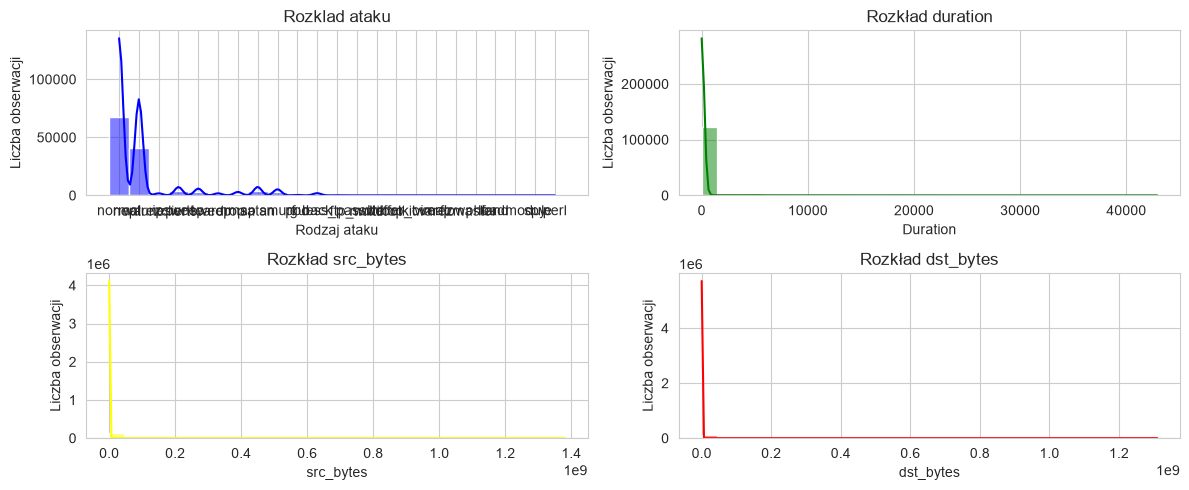

In [16]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)

sns.histplot(df_train['label'], bins=30, kde=True, color="blue")
plt.xlabel("Rodzaj ataku")
plt.ylabel('Liczba obserwacji')
plt.title("Rozklad ataku")

plt.subplot(2, 2, 2)
sns.histplot(df_train['duration'], bins=30, kde=True, color="green")
plt.xlabel("Duration")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład duration")

plt.subplot(2, 2, 3)
sns.histplot(df_train['src_bytes'], bins=30, kde=True, color="yellow")
plt.xlabel("src_bytes")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład src_bytes")

plt.subplot(2, 2, 4)
sns.histplot(df_train['dst_bytes'], bins=30, kde=True, color="red")
plt.xlabel("dst_bytes")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład dst_bytes")
  
plt.tight_layout()
plt.show()

In [ ]:
#obserwacja: kolujny src_bytes, dst_bytes, duration maja bardzo wysokie std
#wzgedem mean - bedzie potrzebnyfeature scaling przed modelowaniem

In [ ]:
#correlation mattix

correlation_matrix = df_train.select_dtypes(include="number").corr()



plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=False,  cmap='coolwarm', linewidths=0.5)
plt.title('Macierz korelacji')
plt.show()

In [ ]:
correlation_matrix['binary_label']

In [ ]:
df_test['binary_label'] = (df_test['label'] != 'normal').astype(int)

X_train = df_train.drop(['label', 'binary_label', 'difficulty_level'], axis=1)
y_train = df_train['binary_label']


X_test = df_test.drop(['label', 'binary_label', 'difficulty_level'], axis=1)
y_test = df_test['binary_label']

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

In [ ]:
X_train

In [ ]:
X_train = pd.get_dummies(X_train, columns=['protocol_type', 'service', 'flag'])
X_test = pd.get_dummies(X_test, columns=['protocol_type', 'service', 'flag'])

X_train

In [ ]:
print(X_train.shape, X_test.shape)

In [ ]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
print(X_train.shape)
print(X_test.shape)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred ))

In [ ]:
# precision 0.92 - jesli model krzyczy "atak"  - ma racje na 92% - malo falszywych alarmow
# recall 0.64 - ze wszystkich atakow model wykryl poprawnie tylko 64% czyli 36% przeszlo niezauwazonych.
# CEL - podbic recall